In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import os
import warnings

##### 0. Settings & Configuration  #####

# Set plot style
sns.set_theme(style="white")
sns.set_theme(style="ticks")

# Ignore warnings
warnings.filterwarnings('ignore')

# Create output directories
if not os.path.exists("output"):
    os.makedirs("output")

In [6]:


##### 1. Data Loading #####
df = pd.read_csv( "Chicago taxi trips of 2023 (raw data).csv")


##### 1.1 Data Cleaning & Preprocessing  #####
# Convert timestamps to datetime objects
df['trip_start_timestamp'] = pd.to_datetime(df['trip_start_timestamp'])
df['trip_end_timestamp'] = pd.to_datetime(df['trip_end_timestamp'])

# Calculate Trip Minutes
df['trip_minutes'] = df['trip_seconds'] / 60

# Data Cleaning: Remove outliers (positive values required, exclude extreme outliers)
# Valid trips have miles > 0, fare > 0, time > 1 min, miles < 100
df_clean = df[
    (df['trip_miles'] > 0) & 
    (df['trip_total'] > 0) & 
    (df['trip_minutes'] > 1) & 
    (df['trip_miles'] < 100) &
    (df['pickup_community_area'].notna()) &
    (df['company'].notna())
].copy()

print(f"Original Records: {len(df)}, Cleaned Records: {len(df_clean)}")

Original Records: 178284, Cleaned Records: 155571


In [7]:
##### 2. Descriptive Analysis: Popular Locations #####

# Count trips by Pickup Community Area
#Counts how many trips originated from each community area, then converts to DataFrame
area_counts = df_clean['pickup_community_area'].value_counts().reset_index()
#Renames the columns for clarity
area_counts.columns = ['Community Area', 'Trip Count']

# Select Top 10 Popular Areas
top_10_areas = area_counts.head(10)

# Add Community Area Name Mapping
#Creates a dictionary mapping area codes to descriptive names
area_mapping = {
    8: "Near North Side (Commercial/Nightlife)",
    32: "Loop (Central Business District)",
    76: "O'Hare (Airport)",
    28: "Near West Side (UIC/Medical Center)",
    6: "Lake View",
    7: "Lincoln Park",
    24: "West Town",
    33: "Near South Side",
    22: "Logan Square",
    56: "Garfield Ridge (Midway Airport)"
}

# Map the names
#Adds a new column with descriptive names by mapping area codes
top_10_areas['Community Name'] = top_10_areas['Community Area'].map(area_mapping).fillna('Other')

print("\nTop 10 Popular Pickup Areas with Location Names:")
display(top_10_areas)

# Save popular areas statistics
top_10_areas.to_csv("output/Top10_Pickup_Areas.csv", index=False)

# Filter data to include only Top 10 areas for further analysis
#Creates a new DataFrame containing only trips from the top 10 areas
df_popular = df_clean[df_clean['pickup_community_area'].isin(top_10_areas['Community Area'])]


Top 10 Popular Pickup Areas with Location Names:


,Community Area,Trip Count,Community Name
0,8.0,36102,Near North Side (Commercial/Nightlife)
1,76.0,27477,O'Hare (Airport)
2,32.0,25087,Loop (Central Business District)
3,28.0,16592,Near West Side (UIC/Medical Center)
4,56.0,5316,Garfield Ridge (Midway Airport)
5,6.0,5165,Lake View
6,33.0,4615,Near South Side
7,7.0,3159,Lincoln Park
8,3.0,2891,Other
9,77.0,2215,Other


In [8]:
##### 2.1 Identify Leading Company #####

# Calculate market share by company within popular areas
#Counts trips by company within popular areas, converts to DataFrame
company_counts = df_popular['company'].value_counts().reset_index()
#Renames columns for clarity
company_counts.columns = ['Company', 'Trip Count']

# Identify the market leader (Benchmark Company)
#Gets the company name from the first row (highest count)
leading_company = company_counts.iloc[0]['Company']
print(f"\nMarket Leading Company in Popular Areas: {leading_company}")

# Save company ranking
company_counts.to_csv("output/Company_Market_Share.csv", index=False)
company_counts.head(10)


Market Leading Company in Popular Areas: Flash Cab


,Company,Trip Count
0,Flash Cab,23046
1,Taxi Affiliation Services,18708
2,Sun Taxi,16842
3,Taxicab Insurance Agency Llc,15268
4,City Service,13023
5,Chicago Independents,8075
6,5 Star Taxi,6331
7,Globe Taxi,5532
8,Blue Ribbon Taxi Association,5170
9,Medallion Leasin,4881


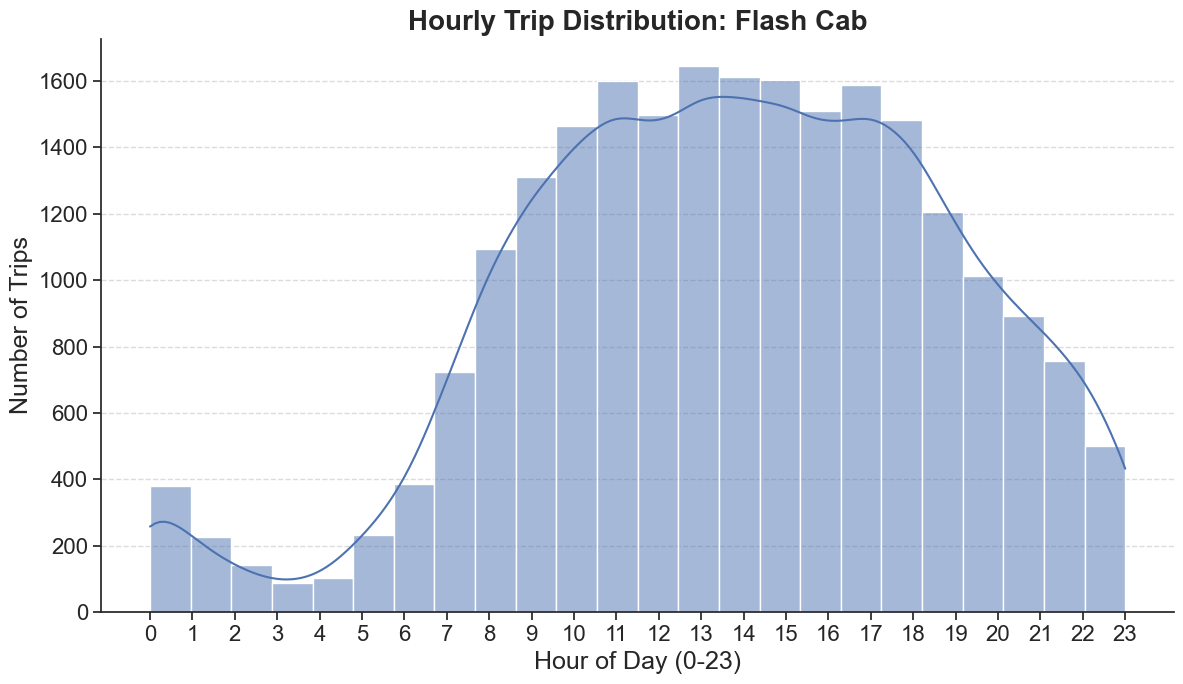

In [9]:
##### 3. Temporal Analysis of Leading Company #####

# Extract data for the leading company
#Creates a new DataFrame with only the leading company's trips
df_leader = df_popular[df_popular['company'] == leading_company].copy()

# Extract hour from timestamp
df_leader['pickup_hour'] = df_leader['trip_start_timestamp'].dt.hour

# Plot: Temporal distribution of orders for the leading company
plt.figure(figsize=(12, 7))

# Use Histogram/Countplot
# Creates a histogram with 24 bins (one per hour) with blue color and density curve
ax = sns.histplot(data=df_leader, x='pickup_hour', bins=24, color='#4c72b0', kde=True)

# Set title and label
#Sets the plot title with large bold font
plt.title(f'Hourly Trip Distribution: {leading_company}', fontsize=20, fontweight='bold')
plt.xlabel('Hour of Day (0-23)', fontsize=18)
plt.ylabel('Number of Trips', fontsize=18)

# Set ticks
#Sets x-axis ticks to show all hours 0-23 with size 16 font
plt.xticks(range(0, 24), fontsize=16)
plt.yticks(fontsize=16)

# Set grid lines
#Adds horizontal grid lines with dashed style and partial transparency
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Despine
#Removes the top and right plot borders
sns.despine()

# Tight layout and save
plt.tight_layout()
plt.savefig("output/Leading_Company_Hourly_Trend.png", dpi=500, bbox_inches='tight', facecolor='white')
plt.show()

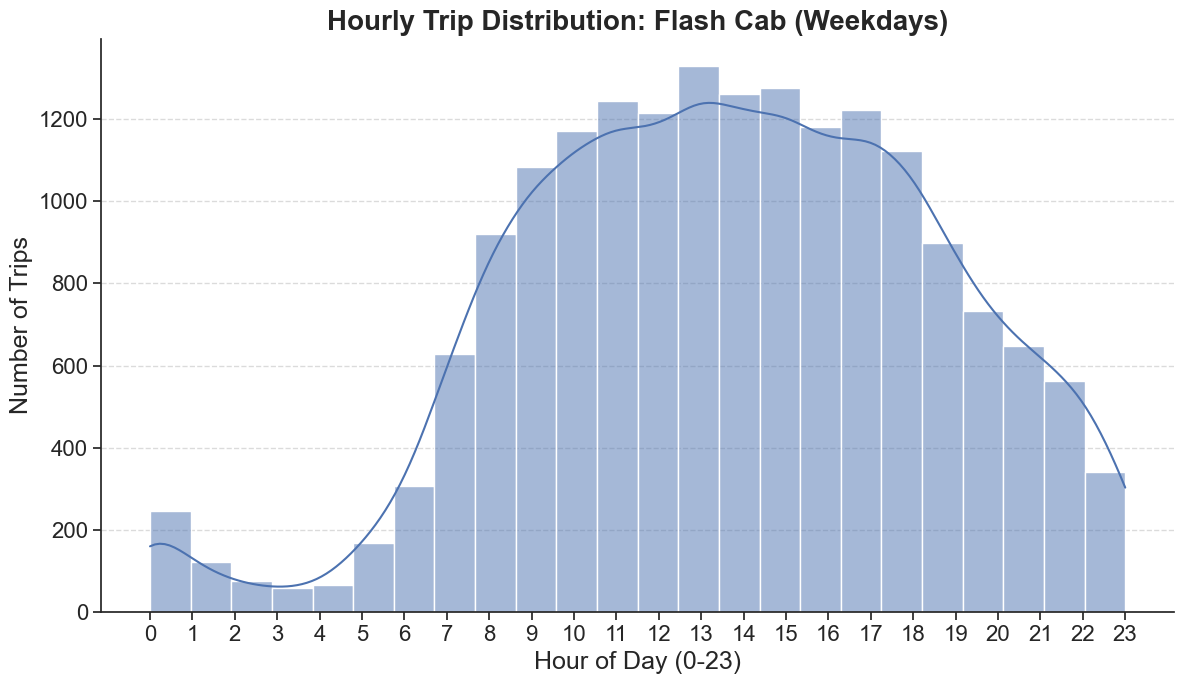

In [10]:
##### 3.2 Temporal Analysis of Leading Company on Weekdays #####

# Extract hour from timestamp
df_leader['pickup_hour'] = df_leader['trip_start_timestamp'].dt.hour

# Create weekend/weekday indicator
df_leader['is_weekend'] = df_leader['trip_start_timestamp'].dt.dayofweek >= 5

# Plot for WEEKDAYS
plt.figure(figsize=(12, 7))

#Filters the data to keep only weekday trips (Monday-Friday)
df_weekdays = df_leader[df_leader['is_weekend'] == False]

## Use Histogram/Countplot
# Creates a histogram with 24 bins (one per hour) with blue color and density curve
ax1 = sns.histplot(data=df_weekdays, x='pickup_hour', bins=24, color='#4c72b0', kde=True)

# Adds a descriptive title with the company name
#Sets the plot title with large bold font
plt.title(f'Hourly Trip Distribution: {leading_company} (Weekdays)', fontsize=20, fontweight='bold')

#Labels the x and y axes
#Labels the x-axis with font size 18
plt.xlabel('Hour of Day (0-23)', fontsize=18)
plt.ylabel('Number of Trips', fontsize=18)

#Sets tick marks for all 24 hours and adjusts font sizes
#Sets x-axis ticks to show all hours 0-23 with size 16 font
plt.xticks(range(0, 24), fontsize=16)
plt.yticks(fontsize=16)

#Adds horizontal grid lines with dashed style and transparency
plt.grid(axis='y', linestyle='--', alpha=0.7)

#Removes the top and right borders for cleaner look
sns.despine()

#Final formatting, high-quality saving, and display
plt.tight_layout()
plt.savefig("output/Leading_Company_Weekdays_Hourly_Trend.png", dpi=500, bbox_inches='tight', facecolor='white')
plt.show()

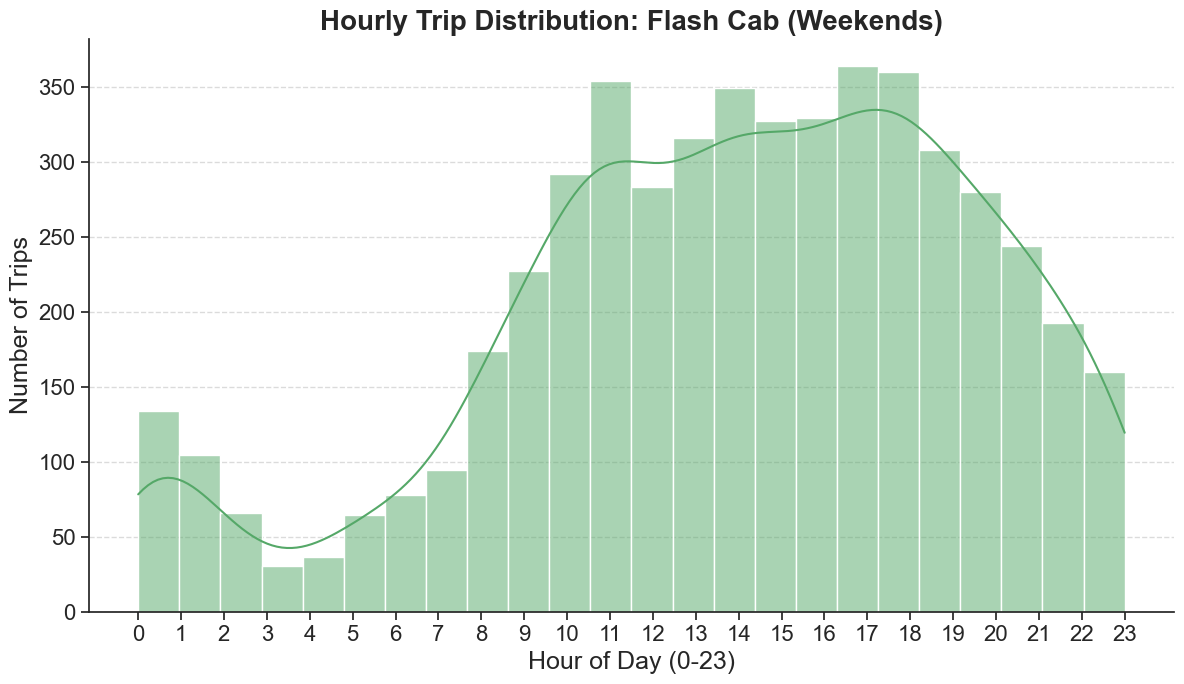

In [11]:
##### 3.3 Temporal Analysis of Leading Company on Weekends #####

# Plot for WEEKENDS
plt.figure(figsize=(12, 7))

#Filters the data to keep only weekend trips (Saturday-Sunday)
df_weekends = df_leader[df_leader['is_weekend'] == True]

# Use Histogram/Countplot
ax2 = sns.histplot(data=df_weekends, x='pickup_hour', bins=24, color='#55a868', kde=True)

#Adds a descriptive title with the company name
plt.title(f'Hourly Trip Distribution: {leading_company} (Weekends)', fontsize=20, fontweight='bold')

#Labels the x and y axes
plt.xlabel('Hour of Day (0-23)', fontsize=18)
plt.ylabel('Number of Trips', fontsize=18)

#Sets tick marks for all 24 hours and adjusts font sizes
plt.xticks(range(0, 24), fontsize=16)
plt.yticks(fontsize=16)

#Adds horizontal grid lines with dashed style and transparency
plt.grid(axis='y', linestyle='--', alpha=0.7)

#Removes the top and right borders for cleaner look
sns.despine()

#Final formatting, high-quality saving, and display
plt.tight_layout()
plt.savefig("output/Leading_Company_Weekends_Hourly_Trend.png", dpi=500, bbox_inches='tight', facecolor='white')
plt.show()




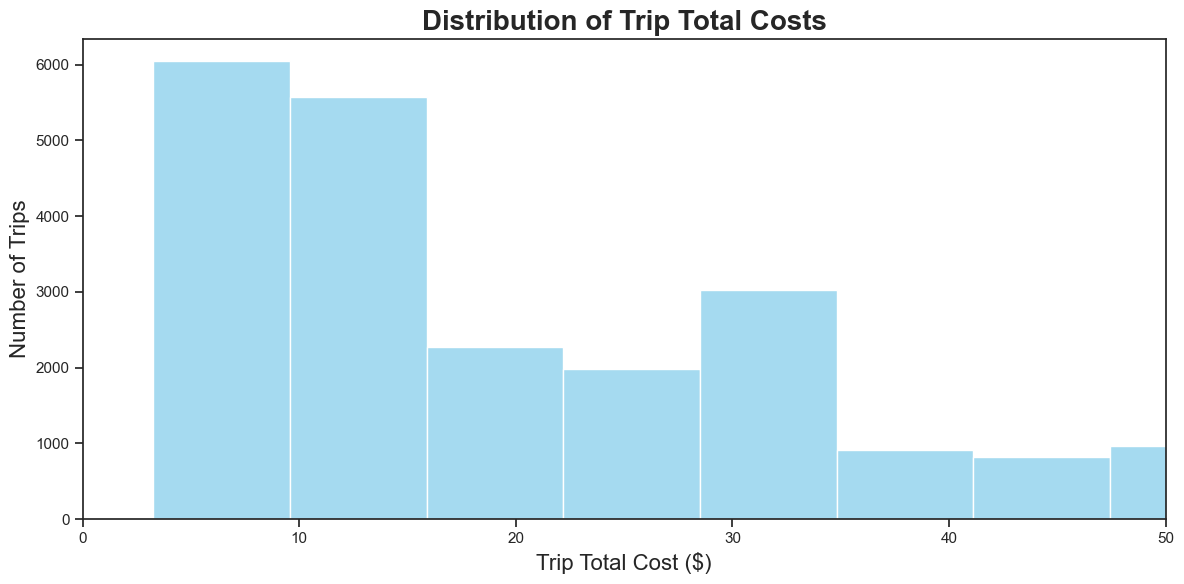

In [12]:
##### Other desciptive analysis of Leading Company #####

# Plot for Trip Cost Distribution
plt.figure(figsize=(12, 6))
sns.histplot(data=df_leader, x='trip_total', bins=50, color='skyblue')
plt.title('Distribution of Trip Total Costs', fontsize=20, fontweight='bold')
plt.xlabel('Trip Total Cost ($)', fontsize=16)
plt.ylabel('Number of Trips', fontsize=16)
plt.xlim(0, 50)  # Focus on most common range
plt.tight_layout()
plt.savefig("output/Trip_Cost_Distribution.png", dpi=500, bbox_inches='tight', facecolor='white')
plt.show()

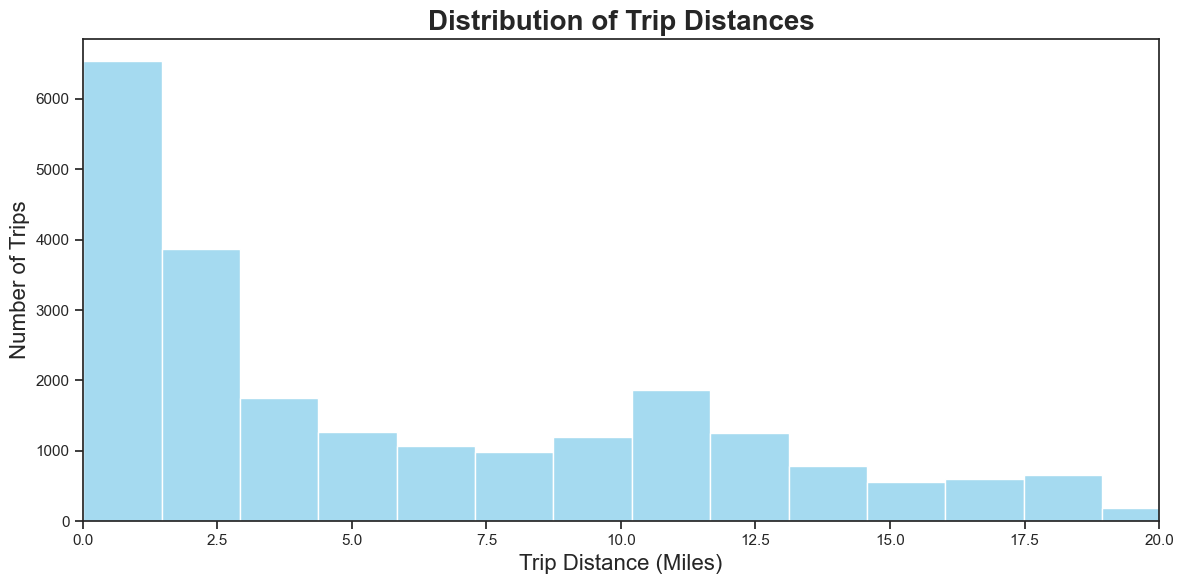

In [13]:
# Plot for Trip Distance Distribution
plt.figure(figsize=(12, 6))
sns.histplot(data=df_leader, x='trip_miles', bins=50, color='skyblue')
plt.title('Distribution of Trip Distances', fontsize=20, fontweight='bold')
plt.xlabel('Trip Distance (Miles)', fontsize=16)
plt.ylabel('Number of Trips', fontsize=16)
plt.xlim(0, 20)  # Focus on most common range
plt.tight_layout()
plt.savefig("output/Trip_Distance_Distribution.png", dpi=500, bbox_inches='tight', facecolor='white')
plt.show()

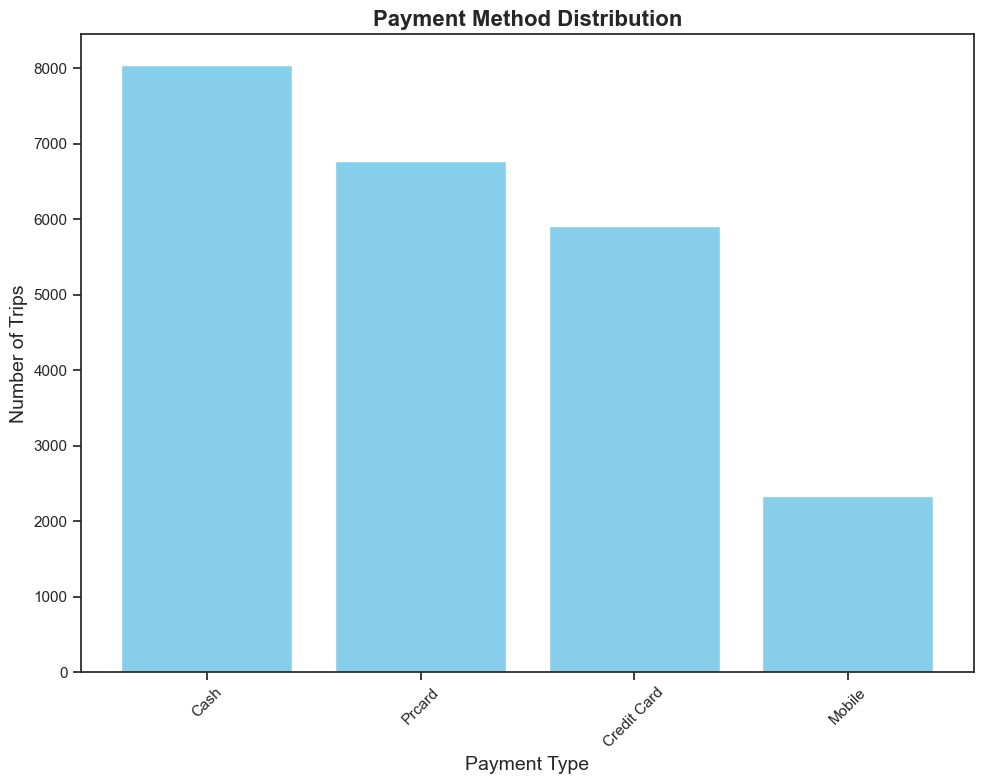

In [14]:
# Plot for Payment Methods
payment_counts = df_leader['payment_type'].value_counts().head(5)
plt.figure(figsize=(10, 8))
plt.bar(payment_counts.index, payment_counts.values, color='skyblue')
plt.title('Payment Method Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Payment Type', fontsize=14)
plt.ylabel('Number of Trips', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("output/Payment_Method_BarChart.png", dpi=500, bbox_inches='tight', facecolor='white')
plt.show()

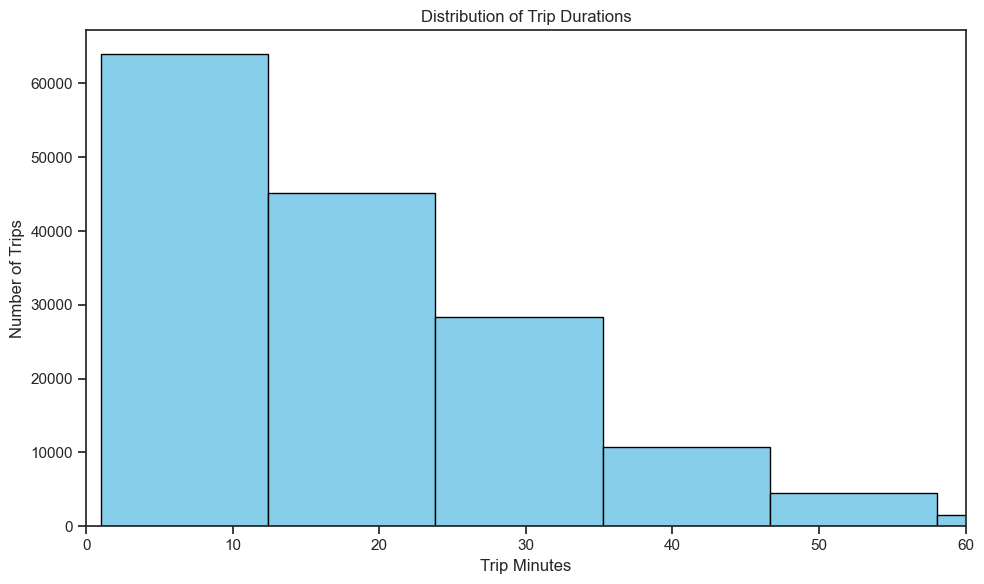

In [15]:
# Simple Trip Minutes Histogram
plt.figure(figsize=(10, 6))
plt.hist(df_clean['trip_minutes'], bins=120, color='skyblue', edgecolor='black')
plt.title('Distribution of Trip Durations')
plt.xlabel('Trip Minutes')
plt.ylabel('Number of Trips')
plt.xlim(0, 60)  # Focus on most common range
plt.tight_layout()
plt.savefig("output/Trip_Minutes_Distribution.png")
plt.show()

In [18]:

##### 4. Explanatory Analysis: Low-Price Strategy Test  #####

# Goal: Test H1 - Does the leading company have lower costs controlling for miles/time?

# For model robustness, select Top 5 companies for comparison
top_5_companies = company_counts.head(5)['Company'].tolist()
df_regression = df_popular[df_popular['company'].isin(top_5_companies)].copy()

In [19]:
##### 4.1 Feature Engineering  #####

# Create control variable
## Create control variable: is_weekday
df_regression['is_weekday'] = df_regression['trip_start_timestamp'].dt.dayofweek < 5
## Create control variable: is_work_hour
df_regression['hour'] = df_regression['trip_start_timestamp'].dt.hour
df_regression['is_work_hour'] = (
    (df_regression['is_weekday']) &
    (df_regression['hour'].between(7,9) | df_regression['hour'].between(16,18))
).astype(int)
## Create control variable: is_rush_hour
df_regression['is_rush_hour'] = (
    (df_regression['is_weekday']) & 
    (df_regression['hour'].between(11, 15))
).astype(int)

# Prepare Regression Variables
## Dependent Variable: Trip Total
Y = df_regression['trip_total']

## Independent Variables: Miles, Minutes, Rush Hour
X_numeric = df_regression[['trip_miles', 'trip_minutes', 'is_weekday', 'is_rush_hour', 'is_work_hour']]

## Create dummy variables for Payment Type
df_regression['payment_type_simplified'] = df_regression['payment_type'].apply(
    lambda x: x if x in ['Cash', 'Credit Card'] else 'Other')
## Handle Categorical Variables: Company and Payment Type
dummies_company = pd.get_dummies(df_regression['company'], prefix='Comp', dtype=int)
dummies_payment = pd.get_dummies(df_regression['payment_type_simplified'], prefix='Pay', drop_first=True, dtype=int)

leader_col_name = f"Comp_{leading_company}"
if leader_col_name in dummies_company.columns:
    dummies_company = dummies_company.drop(columns=[leader_col_name])

# Combine all independent variables
X = pd.concat([X_numeric, dummies_company, dummies_payment], axis=1)

X = X.astype(float)

# Add constant (intercept)
X = sm.add_constant(X)

In [20]:
##### 4.2 Model Building & Visualization  #####

# Build OLS Regression Model
model = sm.OLS(Y, X).fit()

# Extract regression results summary
results_summary = model.summary()
print("\nRegression Analysis Results (Benchmark: Leading Company):")
display(results_summary)

# Organize key coefficients into a table and save
results_df = pd.DataFrame({
    'Variable': model.params.index,
    'Coefficient': model.params.values,
    'Std Error': model.bse.values,
    'P-Value': model.pvalues.values
})

# Mark significance
results_df['Significance'] = results_df['P-Value'].apply(lambda x: '***' if x < 0.001
    else ('**' if x < 0.01 else ('*' if x < 0.05 else '')))
results_df.to_csv("output/Regression_Coefficients.csv", index=False)


Regression Analysis Results (Benchmark: Leading Company):


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             trip_total   R-squared:                       0.798
Model:                            OLS   Adj. R-squared:                  0.798
Method:                 Least Squares   F-statistic:                 3.119e+04
Date:                Fri, 28 Nov 2025   Prob (F-statistic):               0.00
Time:                        18:32:02   Log-Likelihood:            -3.1890e+05
No. Observations:               86887   AIC:                         6.378e+05
Df Residuals:                   86875   BIC:                         6.379e+05
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
=====================================================================================================
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const                                 3.4247      0.103     33.372      0.000       3.224       3.626
trip_miles                            2.5690      0.005    469.021      0.000       2.558       2.580
trip_minutes                          0.0734      0.001     50.746      0.000       0.071       0.076
is_weekday                           -0.3523      0.096     -3.656      0.000      -0.541      -0.163
is_rush_hour                         -1.0780      0.092    -11.718      0.000      -1.258      -0.898
is_work_hour                         -0.8990      0.091     -9.919      0.000      -1.077      -0.721
Comp_City Service                     1.3041      0.105     12.455      0.000       1.099       1.509
Comp_Sun Taxi                         1.5996      0.097     16.474      0.000       1.409       1.790
Comp_Taxi Affiliation Services        6.9689      0.096     72.873      0.000       6.781       7.156
Comp_Taxicab Insurance Agency Llc     2.2352      0.100     22.334      0.000       2.039       2.431
Pay_Credit Card                       6.6137      0.078     84.684      0.000       6.461       6.767
Pay_Other                             1.0425      0.083     12.519      0.000       0.879       1.206
==============================================================================
Omnibus:                    74785.017   Durbin-Watson:                   1.983
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          5075282.636
Skew:                           3.800   Prob(JB):                         0.00
Kurtosis:                      39.662   Cond. No.                         160.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

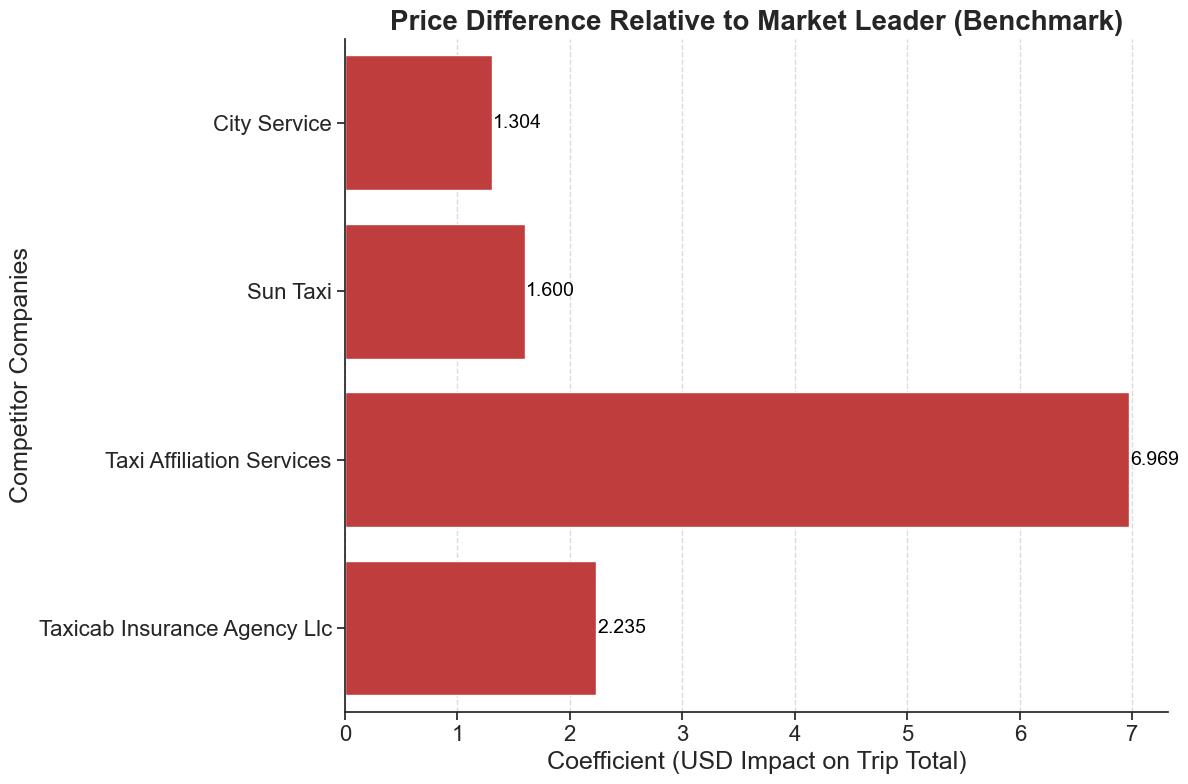

In [21]:
##### 4.3 Coefficient Visualization #####

# Extract only company-related coefficients for plotting to verify price differences
company_coeffs = results_df[results_df['Variable'].str.startswith('Comp_')]

# Plot: Price premium of other companies relative to the benchmark (Leading Company)
plt.figure(figsize=(12, 8))

# Use Barplot
# Color map: Positive (more expensive) -> Red, Negative (cheaper) -> Green
colors = ['#d62728' if c > 0 else '#2ca02c' for c in company_coeffs['Coefficient']]

ax = sns.barplot(
    x='Coefficient', 
    y='Variable', 
    data=company_coeffs, 
    palette=colors
)

# Add value labels 
for p in ax.patches:
    width = p.get_width()    
    y = p.get_y() + p.get_height() / 2  
    
    offset = 0.01 if width >= 0 else -0.01 
    ha = 'left' if width >= 0 else 'right'
    
    ax.text(
        width + offset,     
        y,                   
        f'{width:.3f}',     
        va='center',         
        ha=ha,              
        fontsize=14,        
        color='black'        
    )
    
# Set title and labels
plt.title('Price Difference Relative to Market Leader (Benchmark)', fontsize=20, fontweight='bold')
plt.xlabel('Coefficient (USD Impact on Trip Total)', fontsize=18)
plt.ylabel('Competitor Companies', fontsize=18)

new_labels = [label.get_text().replace('Comp_', '') for label in ax.get_yticklabels()]
ax.set_yticklabels(new_labels, fontsize=16)

# Set X-axis ticks
plt.xticks(fontsize=16)

# Add grid lines
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Despine
sns.despine()

# Tight layout and save
plt.tight_layout()
plt.savefig("output/Company_Price_Comparison.png", dpi=500, bbox_inches='tight', facecolor='white')
plt.show()